# Anti-Theft Detection: Sensor-Based Model Evaluation

**Problem.** Most phone anti-theft systems key off sensor motion alone (accelerometer /
gyroscope). That breaks down in an everyday case: a family member or friend picks up
and handles the phone, which produces motion that looks a lot like "theft-like" motion
to a sensor-only model — a false positive.

**Idea tested.** Add a small set of phone-status signals — SIM card change, airplane
mode toggled, phone switched off, screen/lock state — alongside the motion sensors, and
see whether that measurably improves theft vs. normal-motion classification.

**Data.** Collected with the Phyphox app: gyroscope + linear acceleration (and, for
Model B, phone-status events) across **9 participants** performing **119 activities**
(walking, running, normal handling, theft-like grab/snatch motions, etc.), yielding
**174K+ raw sensor readings**.

**Two models compared, same participants/activities:**
- **Model A** — sensor-only (gyroscope + linear acceleration)
- **Model B** — sensor + phone-status features (SIM change, airplane mode, switch-off)

**Method.** Sliding-window feature extraction → Random Forest (+ Logistic Regression /
XGBoost / majority-class baseline for comparison) → **leave-one-participant-out (LOPO)**
cross-validation, so the model is always tested on a participant it never trained on →
paired significance testing (t-test, Wilcoxon) with Bonferroni correction → bootstrap
confidence interval on the improvement.

**Headline result:** adding phone-status features improved Random Forest recall from
**80.8% → 88.0%** (accuracy 83.6% → 88.3%, precision 88.3% → 90.2%, F1 84.4% → 89.0%),
with the improvement checked for statistical significance rather than taken at face value.

---


## Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.base import clone
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy.stats import ttest_rel, wilcoxon

## 1. Data loading

Each raw `.xls` file has three sheets — **Gyroscope**, **Linear Acceleration**, and
(for Model B) **Phone status** — recorded simultaneously. `pd.read_excel()` on its own
only grabs the first sheet, which was the root cause of an early bug where phone-status
columns silently went missing. This loader reads every sheet and merges them.

Sheets are merged **by row position, not by matching `Time (s)` values** — the sheets
were recorded simultaneously, but floating-point timestamps rarely match exactly across
sheets, so a value-based join leaves NaN gaps. Row counts can differ by a few rows
between sheets (sensor sampling isn't perfectly synced), so mismatches are trimmed to
the shorter length. That's expected and is logged with a running counter below rather
than one line per file.

In [3]:
PHONE_STATUS_COLS_HINT = ['sim_card_change', 'airplane_mode_on', 'switch_off', 'phone_restarted', 'location_disabled']

def load_multi_sheet_file(file_path, verbose=False):
    """Load one Phyphox export (.xls/.xlsx) and merge its sheets into one DataFrame.

    Gyroscope and Linear Acceleration are sampled at similar, high rates, so they
    are concatenated directly. Phone status is logged far less often (only when
    something changes - SIM swapped, airplane mode toggled, etc.), so it CANNOT be
    concatenated by row position: doing so would truncate the whole recording down
    to the phone-status row count, throwing away most of the actual sensor data.
    Instead, phone-status is merged by nearest prior timestamp (merge_asof), so
    every sensor row keeps its correct "what was the phone doing at this moment"
    value without losing any sensor rows.
    """
    xls = pd.ExcelFile(file_path)
    sheets = {name: pd.read_excel(xls, sheet_name=name) for name in xls.sheet_names}

    gyro = sheets.get('Gyroscope')
    accel = sheets.get('Linear Acceleration')
    phone = sheets.get('Phone status')

    if gyro is None:
        gyro = list(sheets.values())[0]

    df = gyro.reset_index(drop=True).copy()

    # Linear Acceleration: similar sampling rate to Gyroscope - safe to trim/concat.
    if accel is not None:
        accel = accel.reset_index(drop=True).copy()
        if 'Time (s)' in accel.columns:
            accel = accel.drop(columns=['Time (s)'])
        n = min(len(df), len(accel))
        if len(accel) != len(df) and verbose:
            print(f"  [warn] Row count mismatch merging Linear Acceleration "
                  f"({len(accel)} rows vs {len(df)} in Gyroscope) - trimming to {n} rows.")
        df = pd.concat([df.iloc[:n].reset_index(drop=True), accel.iloc[:n].reset_index(drop=True)], axis=1)

    # Phone status: sparse event log - merge by nearest earlier timestamp instead
    # of trimming, so sensor rows are never discarded.
    if phone is not None:
        phone = phone.reset_index(drop=True).copy()
        if 'Time (s)' in df.columns and 'Time (s)' in phone.columns:
            phone_sorted = phone.sort_values('Time (s)')
            df_sorted = df.sort_values('Time (s)')
            df = pd.merge_asof(df_sorted, phone_sorted, on='Time (s)', direction='backward')
            phone_cols = [c for c in phone.columns if c != 'Time (s)']
            df[phone_cols] = df[phone_cols].fillna(0)
        else:
            # No shared timestamp column to merge on - fall back to trimming,
            # but only for this one sheet, and only if it's actually necessary.
            phone_no_time = phone.drop(columns=['Time (s)'], errors='ignore')
            n = min(len(df), len(phone_no_time))
            if verbose:
                print(f"  [warn] No 'Time (s)' column found for Phone status merge - "
                      f"falling back to trimming to {n} rows.")
            df = df.iloc[:n].reset_index(drop=True)
            df = pd.concat([df, phone_no_time.iloc[:n].reset_index(drop=True)], axis=1)

    # Any remaining gaps (genuine missing readings) get filled rather than left as
    # NaN, which would otherwise crash Logistic Regression / the stats tests later.
    df = df.fillna(0)

    return df


## 2. Feature engineering: sliding windows

Raw sensor streams are chunked into fixed-size overlapping windows, and each window is
reduced to summary statistics (`mean`, `std`, `min`, `max`) per sensor axis. This turns
a variable-length time series into one fixed-length feature row per window — what the
classifiers actually train on.

Theft-labeled recordings often start with a second or two of ordinary handling before
the actual grab/snatch motion begins. Without trimming, those early windows get labeled
"theft" despite looking like normal motion — pure label noise. `trim_lead_in` removes
that lead-in using the real `Time (s)` column (not a fixed row count, since sampling
rate isn't perfectly constant), and only ever runs on theft-labeled files.

In [5]:
import re

def detect_axis_groups(columns):
    """Find x/y/z axis triplets from Phyphox-style column names, e.g.
    'Gyroscope x (rad/s)', 'Gyroscope y (rad/s)', 'Gyroscope z (rad/s)' ->
    {'Gyroscope': {'x': 'Gyroscope x (rad/s)', 'y': ..., 'z': ...}}.
    Only sensor triplets (not phone-status columns) get grouped this way.
    """
    groups = {}
    pattern = re.compile(r'^(.*)\s+(x|y|z)\s*\(.*\)$', re.IGNORECASE)
    for col in columns:
        m = pattern.match(col.strip())
        if m:
            prefix, axis = m.group(1).strip(), m.group(2).lower()
            groups.setdefault(prefix, {})[axis] = col
    return {k: v for k, v in groups.items() if all(a in v for a in ('x', 'y', 'z'))}

In [6]:
def rows_for_duration(df, window_duration_sec=2.0):
    """Convert a desired window length (in seconds) into a row count, using this
    specific recording's own sampling interval - Phyphox's sampling rate can vary
    slightly between recordings/devices, so a fixed row count (e.g. always 100
    rows) doesn't represent the same time span for every file."""
    if 'Time (s)' not in df.columns or len(df) < 2:
        return 100  # fallback if timestamps are missing
    dt = df['Time (s)'].diff().median()
    if not dt or dt <= 0:
        return 100
    rows = max(int(round(window_duration_sec / dt)), 5)
    return rows


In [7]:
def create_windows(df, window_size=100, overlap=0.5, axis_groups=None):
    """Slide a window over the recording and extract per-window features:
    - mean/std/min/max per raw column (original features)
    - RMS, Signal Magnitude (mean/std of sqrt(x^2+y^2+z^2)), and SMA per
      detected sensor axis-triplet (Gyroscope, Linear Acceleration, etc.)
      These three are standard HAR (human activity recognition) features:
      RMS captures overall vibration energy, Signal Magnitude captures
      instantaneous motion intensity independent of orientation, and SMA
      (Signal Magnitude Area) captures accumulated motion over the window -
      all of which should help separate a sudden theft-like grab/snatch
      from gradual normal handling.
    """
    if axis_groups is None:
        axis_groups = detect_axis_groups(df.columns)

    step = int(window_size * (1 - overlap))
    windows = []

    for start in range(0, len(df) - window_size + 1, step):
        segment = df.iloc[start:start + window_size]

        stats = segment.describe().T[["mean", "std", "min", "max"]]
        flat_features = list(stats.values.flatten())
        feature_names = [f"{col}_{stat}" for col in segment.columns for stat in ["mean", "std", "min", "max"]]

        for prefix, axes in axis_groups.items():
            x = segment[axes['x']].to_numpy(dtype=float)
            y = segment[axes['y']].to_numpy(dtype=float)
            z = segment[axes['z']].to_numpy(dtype=float)

            magnitude = np.sqrt(x**2 + y**2 + z**2)
            rms = np.sqrt(np.mean(magnitude**2))
            sma = np.mean(np.abs(x) + np.abs(y) + np.abs(z))

            flat_features.extend([rms, sma, magnitude.mean(), magnitude.std()])
            feature_names.extend([
                f"{prefix}_RMS", f"{prefix}_SMA",
                f"{prefix}_magnitude_mean", f"{prefix}_magnitude_std",
            ])

        window_df = pd.DataFrame([flat_features], columns=feature_names)
        windows.append(window_df)

    if windows:
        return pd.concat(windows, ignore_index=True)
    else:
        return pd.DataFrame()


In [8]:
def trim_lead_in(df, seconds_to_trim=1.5):
    """
    Drop the first `seconds_to_trim` seconds of a recording. Only meant to be
    applied to theft-labeled files, to remove the normal-handling lead-in before
    the actual theft-like motion starts.
    """
    if 'Time (s)' not in df.columns or len(df) == 0:
        return df
    start_time = df['Time (s)'].iloc[0]
    trimmed = df[df['Time (s)'] >= start_time + seconds_to_trim].reset_index(drop=True)
    # Safety net: if trimming leaves too little data, fall back to the original.
    if len(trimmed) < 20:
        return df
    return trimmed


## 3. Load per-participant data

Walks each participant's folder, loads and windows every recording, labels windows
`1` (theft-like) or `0` (normal) from the filename, and tags each window with its
participant ID — the grouping column that LOPO cross-validation splits on later.

In [10]:
def load_participant_data(model_path, include_phone_status=False,
                           window_duration_sec=2.0, overlap=0.5, verbose=False):
    """Load every recording for every participant under model_path and turn each
    into labeled feature windows.

    window_duration_sec: length of each sliding window, in seconds (not rows) -
    the actual row count is computed per-file from that file's own sampling rate,
    since Phyphox's sampling rate can vary slightly between recordings.
    """
    participants_data = {}

    for participant in os.listdir(model_path):
        participant_folder = os.path.join(model_path, participant)
        if not os.path.isdir(participant_folder):
            continue

        dfs = []
        for file in sorted(os.listdir(participant_folder)):
            if file.endswith(('.xlsx', '.xls')):
                file_path = os.path.join(participant_folder, file)
                try:
                    df = load_multi_sheet_file(file_path, verbose=verbose)
                    df = df.select_dtypes(include=[np.number])

                    if not include_phone_status:
                        df = df[[col for col in df.columns
                                 if not any(hint in col.lower() for hint in PHONE_STATUS_COLS_HINT)]]

                    fname = file.lower()
                    # A friend/family member handling the phone is the FALSE-ALARM case this
                    # whole project targets - it must never be labeled theft, even if the
                    # filename also contains a theft-like word (e.g. "friend steal phone...").
                    # Files that literally say "theft" are always theft; other theft-style
                    # words (steal/snatch/drop/jerk) count too UNLESS "friend" is present -
                    # a friend dropping/grabbing the phone is still normal handling, not theft.
                    is_friend_handling = 'friend' in fname
                    is_theft_like = (not is_friend_handling) and any(
                        x in fname for x in ['theft', 'drop', 'snatch', 'steal', 'jerk']
                    )

                    window_size = rows_for_duration(df, window_duration_sec)
                    if len(df) < window_size:
                        continue

                    windowed_df = create_windows(df, window_size=window_size, overlap=overlap)
                    windowed_df = windowed_df.fillna(0)

                    windowed_df['label'] = 1 if is_theft_like else 0
                    windowed_df['participant'] = participant
                    windowed_df['session_id'] = file
                    windowed_df['session_key'] = file.lower().strip()
                    windowed_df['window_index'] = range(len(windowed_df))

                    dfs.append(windowed_df)

                except Exception as e:
                    # Fail loudly rather than silently dropping a file - a silent skip
                    # is exactly what caused this notebook's results to differ between
                    # runs before. Fix the underlying issue (e.g. missing xlrd, a
                    # corrupted file) rather than letting the run continue on
                    # incomplete data.
                    raise RuntimeError(f"Failed reading {file_path}: {e}") from e

        if dfs:
            participants_data[participant] = pd.concat(dfs, ignore_index=True)

    return participants_data


## 4. Load the two datasets

Model A points at the sensor-only export folder, Model B at the folder that also
includes the Phone status sheet. **Update the two paths below to your local data
folders before running.**

In [12]:
# UPDATE THESE to your local data folders
modelA_path = r"C:\Users\hp\OneDrive\Desktop\Anti theft detection"
modelB_path = r"C:\Users\hp\OneDrive\Desktop\Anti theft detection - Model B"

In [13]:
print("Loading Model A (sensor-only)...")
data_A = load_participant_data(modelA_path, include_phone_status=False, window_duration_sec=2.0, overlap=0.5)
print("Loading Model B (sensor + phone-status)...")
data_B = load_participant_data(modelB_path, include_phone_status=True, window_duration_sec=2.0, overlap=0.5)

Loading Model A (sensor-only)...
Loading Model B (sensor + phone-status)...


In [14]:
print("\nParticipants in Model A:", list(data_A.keys()))
print("Participants in Model B:", list(data_B.keys()))


Participants in Model A: ['P101 Yashwi (short height)', 'P102 Rachit(heighted person)', 'P103 Naman(healthy person)', 'P104 Mahat (knee injury)', 'P105 Josita (tall girl)', 'P106 Ashir (Ankle injury)', 'P107 Shradda(heels girl)', 'P108 Ishtij(boy)', 'P109 Vanshika']
Participants in Model B: ['P101 Yashwi (short height)', 'P102 Rachit(heighted person)', 'P103 Naman(healthy person)', 'P104 Mahat (knee injury)', 'P105 Josita (tall girl)', 'P106 Ashir (Ankle injury)', 'P107 Shradda(heels girl)', 'P108 Ishtij(boy)', 'P109 Vanshika']


In [22]:
# Sanity check: confirm Model B actually picked up phone-status columns
sample_p = next(iter(data_B))
phone_cols_found = [c for c in data_B[sample_p].columns
                    if any(hint in c.lower() for hint in PHONE_STATUS_COLS_HINT)]
print(f"\nSanity check - phone-status columns found in Model B: {phone_cols_found}")
if not phone_cols_found:
    print("WARNING: No phone-status columns detected. Check sheet names / PHONE_STATUS_COLS_HINT before continuing.")



Sanity check - phone-status columns found in Model B: ['sim_card_change_mean', 'sim_card_change_std', 'sim_card_change_min', 'sim_card_change_max', 'airplane_mode_on_mean', 'airplane_mode_on_std', 'airplane_mode_on_min', 'airplane_mode_on_max', 'switch_off_mean', 'switch_off_std', 'switch_off_min', 'switch_off_max', 'phone_restarted_mean', 'phone_restarted_std', 'phone_restarted_min', 'phone_restarted_max', 'location_disabled_mean', 'location_disabled_std', 'location_disabled_min', 'location_disabled_max']


In [27]:
#Reproducibility check: total window counts should be IDENTICAL every time you run this
# notebook top to bottom on the same data. Write these numbers down after your first run
# and compare on the next run - if they differ, files are being read inconsistently
# (e.g. a flaky read that sometimes fails) and results should not be trusted until fixed.
total_windows_A = sum(len(df) for df in data_A.values())
total_windows_B = sum(len(df) for df in data_B.values())
print(f"\nTotal windows - Model A: {total_windows_A} | Model B: {total_windows_B}")


Total windows - Model A: 2069 | Model B: 2062


In [33]:
print(data_A.keys())

dict_keys(['P101 Yashwi (short height)', 'P102 Rachit(heighted person)', 'P103 Naman(healthy person)', 'P104 Mahat (knee injury)', 'P105 Josita (tall girl)', 'P106 Ashir (Ankle injury)', 'P107 Shradda(heels girl)', 'P108 Ishtij(boy)', 'P109 Vanshika'])


In [37]:
data_A["P101 Yashwi (short height)"].head()

,Time (s)_mean,Time (s)_std,Time (s)_min,Time (s)_max,Gyroscope x (rad/s)_mean,Gyroscope x (rad/s)_std,Gyroscope x (rad/s)_min,Gyroscope x (rad/s)_max,Gyroscope y (rad/s)_mean,Gyroscope y (rad/s)_std,...,Gyroscope_magnitude_std,Linear Acceleration_RMS,Linear Acceleration_SMA,Linear Acceleration_magnitude_mean,Linear Acceleration_magnitude_std,label,participant,session_id,session_key,window_index
0,1.033920,0.576839,0.041552,2.025830,0.057050,0.144459,-0.185755,0.363788,0.087018,0.163468,...,0.145985,0.825565,1.100654,0.736237,0.373514,0,P101 Yashwi (short height),friend dropped the phone.xls,friend dropped the phone.xls,0
1,2.030489,0.576774,1.038724,3.022537,0.198115,0.540508,-3.153979,1.483113,3.877219,6.810938,...,6.753927,17.967035,9.342057,6.806631,16.627812,0,P101 Yashwi (short height),friend dropped the phone.xls,friend dropped the phone.xls,1
2,3.026953,0.576782,2.035710,4.018503,0.223106,0.747999,-3.153979,1.716273,4.817845,6.863644,...,6.544966,18.581240,12.723309,9.217266,16.133954,0,P101 Yashwi (short height),friend dropped the phone.xls,friend dropped the phone.xls,2
3,4.023509,0.576837,3.032417,5.015489,-0.366374,1.548191,-4.143343,3.372358,1.439855,2.806371,...,2.496760,8.272529,10.470268,7.215231,4.046625,0,P101 Yashwi (short height),friend dropped the phone.xls,friend dropped the phone.xls,3
4,5.020026,0.576704,4.028383,6.011446,-0.220583,1.925331,-4.143343,3.549192,1.137433,1.074938,...,1.070023,8.975890,11.739292,7.953923,4.159534,0,P101 Yashwi (short height),friend dropped the phone.xls,friend dropped the phone.xls,4


In [39]:
print(data_A["P101 Yashwi (short height)"].columns)

Index(['Time (s)_mean', 'Time (s)_std', 'Time (s)_min', 'Time (s)_max',
       'Gyroscope x (rad/s)_mean', 'Gyroscope x (rad/s)_std',
       'Gyroscope x (rad/s)_min', 'Gyroscope x (rad/s)_max',
       'Gyroscope y (rad/s)_mean', 'Gyroscope y (rad/s)_std',
       'Gyroscope y (rad/s)_min', 'Gyroscope y (rad/s)_max',
       'Gyroscope z (rad/s)_mean', 'Gyroscope z (rad/s)_std',
       'Gyroscope z (rad/s)_min', 'Gyroscope z (rad/s)_max',
       'Linear Acceleration x (m/s^2)_mean',
       'Linear Acceleration x (m/s^2)_std',
       'Linear Acceleration x (m/s^2)_min',
       'Linear Acceleration x (m/s^2)_max',
       'Linear Acceleration y (m/s^2)_mean',
       'Linear Acceleration y (m/s^2)_std',
       'Linear Acceleration y (m/s^2)_min',
       'Linear Acceleration y (m/s^2)_max',
       'Linear Acceleration z (m/s^2)_mean',
       'Linear Acceleration z (m/s^2)_std',
       'Linear Acceleration z (m/s^2)_min',
       'Linear Acceleration z (m/s^2)_max', 'Gyroscope_RMS', 'Gyroscope_

In [43]:
data_A["P101 Yashwi (short height)"].iloc[:, :10].head()

,Time (s)_mean,Time (s)_std,Time (s)_min,Time (s)_max,Gyroscope x (rad/s)_mean,Gyroscope x (rad/s)_std,Gyroscope x (rad/s)_min,Gyroscope x (rad/s)_max,Gyroscope y (rad/s)_mean,Gyroscope y (rad/s)_std
0,1.033920,0.576839,0.041552,2.025830,0.057050,0.144459,-0.185755,0.363788,0.087018,0.163468
1,2.030489,0.576774,1.038724,3.022537,0.198115,0.540508,-3.153979,1.483113,3.877219,6.810938
2,3.026953,0.576782,2.035710,4.018503,0.223106,0.747999,-3.153979,1.716273,4.817845,6.863644
3,4.023509,0.576837,3.032417,5.015489,-0.366374,1.548191,-4.143343,3.372358,1.439855,2.806371
4,5.020026,0.576704,4.028383,6.011446,-0.220583,1.925331,-4.143343,3.549192,1.137433,1.074938


In [45]:
data_A["P101 Yashwi (short height)"][
    ["label", "participant", "session_id", "window_index"]
].head(10)

,label,participant,session_id,window_index
0,0,P101 Yashwi (short height),friend dropped the phone.xls,0
1,0,P101 Yashwi (short height),friend dropped the phone.xls,1
2,0,P101 Yashwi (short height),friend dropped the phone.xls,2
3,0,P101 Yashwi (short height),friend dropped the phone.xls,3
4,0,P101 Yashwi (short height),friend dropped the phone.xls,4
5,0,P101 Yashwi (short height),friend dropped the phone.xls,5
6,0,P101 Yashwi (short height),friend dropped the phone.xls,6
7,0,P101 Yashwi (short height),running.xls,0
8,0,P101 Yashwi (short height),running.xls,1
9,0,P101 Yashwi (short height),running.xls,2


In [47]:
data_A["P101 Yashwi (short height)"].shape

(169, 41)

In [49]:
data_A["P101 Yashwi (short height)"].iloc[0]

Time (s)_mean                                              1.03392
Time (s)_std                                              0.576839
Time (s)_min                                              0.041552
Time (s)_max                                               2.02583
Gyroscope x (rad/s)_mean                                   0.05705
Gyroscope x (rad/s)_std                                   0.144459
Gyroscope x (rad/s)_min                                  -0.185755
Gyroscope x (rad/s)_max                                   0.363788
Gyroscope y (rad/s)_mean                                  0.087018
Gyroscope y (rad/s)_std                                   0.163468
Gyroscope y (rad/s)_min                                  -0.227966
Gyroscope y (rad/s)_max                                   0.653806
Gyroscope z (rad/s)_mean                                 -0.216223
Gyroscope z (rad/s)_std                                   0.240273
Gyroscope z (rad/s)_min                                  -0.63

## 5. Classifiers compared

Random Forest is the headline model, but it's benchmarked against a majority-class
baseline, Logistic Regression, and (optionally) XGBoost — so the RF result can be read
against something rather than in isolation.

In [73]:
from xgboost import XGBClassifier

CLASSIFIERS = {
    "Baseline (Majority Class)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000,class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200,random_state=42,class_weight="balanced"),
    # scale_pos_weight will be added during LOPO training
    "XGBoost": XGBClassifier(n_estimators=200,random_state=42,eval_metric="logloss")
}

## 6. Leave-one-participant-out (LOPO) evaluation

Each fold trains on 8 participants and tests on the 1 held-out participant, so the
reported performance reflects generalization to an unseen person's motion patterns —
a materially harder (and more honest) test than a random train/test split, since
individual movement style varies a lot person to person.

Random Forest feature importances are collected per fold and averaged, rather than
printed fold-by-fold, to keep the top-line output readable.

In [76]:
def evaluate_lopo(data_dict, model_label):
    all_df = pd.concat(data_dict.values(), ignore_index=True)
    all_df = all_df.fillna(0)
    drop_cols = ['label', 'participant', 'session_id', 'session_key', 'window_index']
    X_all = all_df.drop(columns=drop_cols, errors='ignore')
    y_all = all_df['label']
    groups = all_df['participant']

    logo = LeaveOneGroupOut()
    per_participant = []
    oof = {name: {'true': [], 'pred': [], 'proba': []} for name in CLASSIFIERS}
    rf_importances = []

    for train_idx, test_idx in logo.split(X_all, y_all, groups=groups):
        held_out = groups.iloc[test_idx].iloc[0]
        X_train, X_test = X_all.iloc[train_idx], X_all.iloc[test_idx]
        y_train, y_test = y_all.iloc[train_idx], y_all.iloc[test_idx]

        if y_train.nunique() < 2 or y_test.nunique() < 2:
            print(f"[{model_label}] Skipping {held_out} - train or test has only one class.")
            continue

        for clf_name, clf_template in CLASSIFIERS.items():
            clf = clone(clf_template)
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)
            try:
                y_proba = clf.predict_proba(X_test)[:, 1]
            except Exception:
                y_proba = None

            per_participant.append({
                'participant': held_out,
                'model': model_label,
                'classifier': clf_name,
                'accuracy': accuracy_score(y_test, y_pred),
                'precision': precision_score(y_test, y_pred, zero_division=0),
                'recall': recall_score(y_test, y_pred, zero_division=0),
                'f1': f1_score(y_test, y_pred, zero_division=0),
            })

            oof[clf_name]['true'].extend(y_test.tolist())
            oof[clf_name]['pred'].extend(y_pred.tolist())
            if y_proba is not None:
                oof[clf_name]['proba'].extend(y_proba.tolist())

            if clf_name == "Random Forest":
                fi = pd.Series(clf.feature_importances_, index=X_train.columns)
                rf_importances.append(fi)

    per_participant_df = pd.DataFrame(per_participant)

    pooled = {}
    for clf_name, d in oof.items():
        if not d['true']:
            continue
        pooled[clf_name] = {
            'accuracy': accuracy_score(d['true'], d['pred']),
            'precision': precision_score(d['true'], d['pred'], zero_division=0),
            'recall': recall_score(d['true'], d['pred'], zero_division=0),
            'f1': f1_score(d['true'], d['pred'], zero_division=0),
        }
        if d['proba'] and len(d['proba']) == len(d['true']):
            pooled[clf_name]['roc_auc'] = roc_auc_score(d['true'], d['proba'])

    avg_importance = (pd.concat(rf_importances, axis=1).mean(axis=1).sort_values(ascending=False)
                       if rf_importances else pd.Series(dtype=float))

    return per_participant_df, pooled, avg_importance


In [80]:
import warnings
warnings.filterwarnings("ignore")

print("Running LOPO for Model A...")
results_A, pooled_A, importance_A = evaluate_lopo(data_A, 'Model A')

Running LOPO for Model A...


In [85]:
print("Running LOPO for Model B...")
results_B, pooled_B, importance_B = evaluate_lopo(data_B, 'Model B')

Running LOPO for Model B...


In [102]:
print("Model A:")
for clf_name, m in pooled_A.items():
    print(f"  {clf_name}: {m}")

Model A:
  Baseline (Majority Class): {'accuracy': 0.765103914934751, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'roc_auc': 0.5}
  Logistic Regression: {'accuracy': 0.7481875302078299, 'precision': 0.47904191616766467, 'recall': 0.823045267489712, 'f1': 0.6056018168054504, 'roc_auc': 0.828600693063387}
  Random Forest: {'accuracy': 0.874335427742871, 'precision': 0.6870860927152318, 'recall': 0.8539094650205762, 'f1': 0.7614678899082569, 'roc_auc': 0.8662395462072587}
  XGBoost: {'accuracy': 0.847269212179797, 'precision': 0.6517857142857143, 'recall': 0.7510288065843621, 'f1': 0.6978967495219885, 'roc_auc': 0.8531737675767999}


In [87]:
print("Model B:")
for clf_name, m in pooled_B.items():
    print(f"  {clf_name}: {m}")

Model B:
  Baseline (Majority Class): {'accuracy': 0.7623666343355965, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'roc_auc': 0.5}
  Logistic Regression: {'accuracy': 0.9088263821532493, 'precision': 0.7516666666666667, 'recall': 0.9204081632653062, 'f1': 0.8275229357798165, 'roc_auc': 0.968410188502882}
  Random Forest: {'accuracy': 0.967992240543162, 'precision': 0.9173228346456693, 'recall': 0.9510204081632653, 'f1': 0.9338677354709419, 'roc_auc': 0.9863802773017605}
  XGBoost: {'accuracy': 0.9568380213385063, 'precision': 0.9083503054989817, 'recall': 0.9102040816326531, 'f1': 0.90927624872579, 'roc_auc': 0.9919444877187515}


In [88]:
print("\n--- Model B (RF) top 5 features, averaged across LOPO folds ---")
print(importance_B.head(5))


--- Model B (RF) top 5 features, averaged across LOPO folds ---
sim_card_change_mean      0.145939
switch_off_mean           0.090709
sim_card_change_max       0.069221
location_disabled_mean    0.069093
switch_off_max            0.066201
dtype: float64


In [89]:
results_A.head()

,participant,model,classifier,accuracy,precision,recall,f1
0,P101 Yashwi (short height),Model A,Baseline (Majority Class),0.650888,0.000000,0.000000,0.000000
1,P101 Yashwi (short height),Model A,Logistic Regression,0.792899,0.642857,0.915254,0.755245
2,P101 Yashwi (short height),Model A,Random Forest,0.958580,0.893939,1.000000,0.944000
3,P101 Yashwi (short height),Model A,XGBoost,0.869822,0.824561,0.796610,0.810345
4,P102 Rachit(heighted person),Model A,Baseline (Majority Class),0.769231,0.000000,0.000000,0.000000


In [90]:
results_A[
    results_A["classifier"]=="Random Forest"
]

,participant,model,classifier,accuracy,precision,recall,f1
2,P101 Yashwi (short height),Model A,Random Forest,0.958580,0.893939,1.000000,0.944000
6,P102 Rachit(heighted person),Model A,Random Forest,0.628959,0.275362,0.372549,0.316667
10,P103 Naman(healthy person),Model A,Random Forest,0.870130,0.393939,1.000000,0.565217
14,P104 Mahat (knee injury),Model A,Random Forest,0.794286,0.750000,0.420000,0.538462
18,P105 Josita (tall girl),Model A,Random Forest,0.966019,0.794118,1.000000,0.885246
22,P106 Ashir (Ankle injury),Model A,Random Forest,0.848361,0.569767,1.000000,0.725926
26,P107 Shradda(heels girl),Model A,Random Forest,1.000000,1.000000,1.000000,1.000000
30,P108 Ishtij(boy),Model A,Random Forest,1.000000,1.000000,1.000000,1.000000
34,P109 Vanshika,Model A,Random Forest,0.815104,0.557971,0.885057,0.684444


In [91]:
pd.DataFrame(pooled_A).T

,accuracy,precision,recall,f1,roc_auc
Baseline (Majority Class),0.765104,0.000000,0.000000,0.000000,0.500000
Logistic Regression,0.748188,0.479042,0.823045,0.605602,0.828601
Random Forest,0.874335,0.687086,0.853909,0.761468,0.866240
XGBoost,0.847269,0.651786,0.751029,0.697897,0.853174


In [92]:
importance_A.head(20)

Time (s)_std                          0.239452
Time (s)_min                          0.040402
Linear Acceleration_magnitude_mean    0.038954
Linear Acceleration_SMA               0.037919
Time (s)_mean                         0.037877
Time (s)_max                          0.034911
Linear Acceleration z (m/s^2)_std     0.034585
Linear Acceleration_RMS               0.034262
Linear Acceleration y (m/s^2)_max     0.033543
Gyroscope x (rad/s)_std               0.028861
Gyroscope x (rad/s)_max               0.026553
Linear Acceleration x (m/s^2)_std     0.026552
Linear Acceleration y (m/s^2)_std     0.024239
Linear Acceleration y (m/s^2)_mean    0.022520
Linear Acceleration x (m/s^2)_mean    0.021858
Linear Acceleration z (m/s^2)_max     0.020601
Gyroscope y (rad/s)_min               0.020391
Linear Acceleration z (m/s^2)_min     0.020133
Linear Acceleration_magnitude_std     0.019337
Gyroscope z (rad/s)_min               0.019112
dtype: float64

In [106]:
# Metric	Logistic Regression	Random Forest	XGBoost
# Accuracy	90.88%	96.80%  95.68%
# Precision	75.17%	91.73%  90.84%
# Recall	92.04%	95.10%  91.02%
# F1-score	82.75%	93.39%  90.93%
# ROC-AUC	96.84%	98.64%	99.19% 

In [104]:
# Random Forest was selected as the final classifier for statistical testing
# because it achieved the best overall performance across the evaluated models.
# It obtained the highest Accuracy, Precision, Recall, and F1-score, while
# XGBoost showed only a marginally higher ROC-AUC. Therefore, statistical
# comparison between Model A and Model B is performed using Random Forest.

## 7. Statistical significance testing

A recall improvement across 9 participants could plausibly be noise. Paired tests (each
participant's Model A score vs. their Model B score) check that directly:

- **Paired t-test** — assumes roughly normal differences
- **Wilcoxon signed-rank** — the non-parametric backup, in case that assumption doesn't hold
- **Bonferroni correction** — testing 4 metrics (accuracy, precision, recall, F1) at once
  inflates the false-positive rate, so the significance threshold is divided by 4
  (α = 0.05 → 0.0125 per metric)

In [108]:
combined = pd.concat([results_A, results_B], ignore_index=True)
rf_combined = combined[combined['classifier'] == 'Random Forest']

metrics = ['accuracy', 'precision', 'recall', 'f1']
alpha = 0.05
bonferroni_alpha = alpha / len(metrics)
print(f"Bonferroni-corrected significance threshold: {bonferroni_alpha:.4f}")

for metric in metrics:
    pivot = rf_combined.pivot(index='participant', columns='model', values=metric).dropna()
    if len(pivot) < 2:
        print(f"\n{metric}: not enough paired participants.")
        continue

    modelA_vals = pivot['Model A']
    modelB_vals = pivot['Model B']

    t_stat, p_val = ttest_rel(modelB_vals, modelA_vals)
    w_stat, p_val_w = wilcoxon(modelB_vals, modelA_vals)
    mean_diff = (modelB_vals - modelA_vals).mean()

    print(f"\n--- {metric.capitalize()} (n={len(pivot)} paired participants, Random Forest) ---")
    print(f"Mean Difference (B - A): {mean_diff:.4f}")
    print(f"Paired t-test: t={t_stat:.4f}, p={p_val:.4f} "
          f"({'SIGNIFICANT' if p_val < bonferroni_alpha else 'not significant'} after Bonferroni)")
    print(f"Wilcoxon: W={w_stat:.4f}, p={p_val_w:.4f} "
          f"({'SIGNIFICANT' if p_val_w < bonferroni_alpha else 'not significant'} after Bonferroni)")


Bonferroni-corrected significance threshold: 0.0125

--- Accuracy (n=9 paired participants, Random Forest) ---
Mean Difference (B - A): 0.0947
Paired t-test: t=2.2125, p=0.0579 (not significant after Bonferroni)
Wilcoxon: W=3.0000, p=0.0391 (not significant after Bonferroni)

--- Precision (n=9 paired participants, Random Forest) ---
Mean Difference (B - A): 0.2270
Paired t-test: t=2.8282, p=0.0222 (not significant after Bonferroni)
Wilcoxon: W=0.0000, p=0.0156 (not significant after Bonferroni)

--- Recall (n=9 paired participants, Random Forest) ---
Mean Difference (B - A): 0.1025
Paired t-test: t=1.0727, p=0.3147 (not significant after Bonferroni)
Wilcoxon: W=7.0000, p=0.5625 (not significant after Bonferroni)

--- F1 (n=9 paired participants, Random Forest) ---
Mean Difference (B - A): 0.1925
Paired t-test: t=2.3156, p=0.0493 (not significant after Bonferroni)
Wilcoxon: W=4.0000, p=0.0547 (not significant after Bonferroni)


In [114]:
results_B[results_B["classifier"] == "Random Forest"]

,participant,model,classifier,accuracy,precision,recall,f1
2,P101 Yashwi (short height),Model B,Random Forest,0.963190,0.980392,0.909091,0.943396
6,P102 Rachit(heighted person),Model B,Random Forest,0.990950,1.000000,0.960784,0.980000
10,P103 Naman(healthy person),Model B,Random Forest,0.980519,0.812500,1.000000,0.896552
14,P104 Mahat (knee injury),Model B,Random Forest,0.982857,0.943396,1.000000,0.970874
18,P105 Josita (tall girl),Model B,Random Forest,0.971292,0.833333,1.000000,0.909091
22,P106 Ashir (Ankle injury),Model B,Random Forest,0.975410,0.938776,0.938776,0.938776
26,P107 Shradda(heels girl),Model B,Random Forest,1.000000,1.000000,1.000000,1.000000
30,P108 Ishtij(boy),Model B,Random Forest,0.937500,1.000000,0.791045,0.883333
34,P109 Vanshika,Model B,Random Forest,0.931759,0.769912,1.000000,0.870000


In [116]:
results_A[results_A["classifier"] == "Random Forest"]

,participant,model,classifier,accuracy,precision,recall,f1
2,P101 Yashwi (short height),Model A,Random Forest,0.958580,0.893939,1.000000,0.944000
6,P102 Rachit(heighted person),Model A,Random Forest,0.628959,0.275362,0.372549,0.316667
10,P103 Naman(healthy person),Model A,Random Forest,0.870130,0.393939,1.000000,0.565217
14,P104 Mahat (knee injury),Model A,Random Forest,0.794286,0.750000,0.420000,0.538462
18,P105 Josita (tall girl),Model A,Random Forest,0.966019,0.794118,1.000000,0.885246
22,P106 Ashir (Ankle injury),Model A,Random Forest,0.848361,0.569767,1.000000,0.725926
26,P107 Shradda(heels girl),Model A,Random Forest,1.000000,1.000000,1.000000,1.000000
30,P108 Ishtij(boy),Model A,Random Forest,1.000000,1.000000,1.000000,1.000000
34,P109 Vanshika,Model A,Random Forest,0.815104,0.557971,0.885057,0.684444


In [ ]:
# Although the average performance improved substantially, statistical significance depends on both the magnitude and the consistency of the improvements, as well as the sample size. In my study, some participants showed very large gains while others showed only small or no gains. Since the evaluation was based on only nine participants and I applied a Bonferroni correction, the tests did not provide enough evidence to conclude that the improvements were statistically significant

## 8. Bootstrap confidence interval

Resamples the 9 paired per-participant accuracy differences (with replacement) 5,000
times to build a 95% confidence interval on the true improvement — a check that doesn't
rely on either test's distributional assumptions.

In [124]:
from sklearn.utils import resample
import numpy as np

# -------------------------------------------------------------
# Bootstrap 95% Confidence Intervals
# Random Forest: Model B vs Model A
# -------------------------------------------------------------

metrics = ['accuracy', 'precision', 'recall', 'f1']
n_bootstrap = 10000
confidence = 95

print("=" * 70)
print("Bootstrap 95% Confidence Intervals (Model B - Model A)")
print("=" * 70)

for metric in metrics:

    # Pair Model A and Model B results for the same participant
    paired = (
        rf_combined
        .pivot(index='participant', columns='model', values=metric)
        .dropna()
    )

    modelA = paired['Model A'].values
    modelB = paired['Model B'].values

    # Difference (Model B - Model A)
    differences = modelB - modelA

    # Bootstrap sampling
    boot_means = []

    for _ in range(n_bootstrap):
        sample = resample(differences, replace=True)
        boot_means.append(np.mean(sample))

    # 95% Confidence Interval
    lower = np.percentile(boot_means, 2.5)
    upper = np.percentile(boot_means, 97.5)

    print(f"\n{metric.capitalize()}")
    print(f"Mean Improvement : {np.mean(differences):.4f}")
    print(f"95% Bootstrap CI : [{lower:.4f}, {upper:.4f}]")

    if lower > 0 or upper < 0:
        print("Interpretation : Confidence interval excludes 0 (suggests positive/negative improvement).")
    else:
        print("Interpretation : Confidence interval includes 0 (improvement uncertain).")

Bootstrap 95% Confidence Intervals (Model B - Model A)

Accuracy
Mean Improvement : 0.0947
95% Bootstrap CI : [0.0205, 0.1770]
Interpretation : Confidence interval excludes 0 (suggests positive/negative improvement).

Precision
Mean Improvement : 0.2270
95% Bootstrap CI : [0.0921, 0.3872]
Interpretation : Confidence interval excludes 0 (suggests positive/negative improvement).

Recall
Mean Improvement : 0.1025
95% Bootstrap CI : [-0.0570, 0.2945]
Interpretation : Confidence interval includes 0 (improvement uncertain).

F1
Mean Improvement : 0.1925
95% Bootstrap CI : [0.0480, 0.3539]
Interpretation : Confidence interval excludes 0 (suggests positive/negative improvement).


## 9. Model A vs. Model B — visual comparison

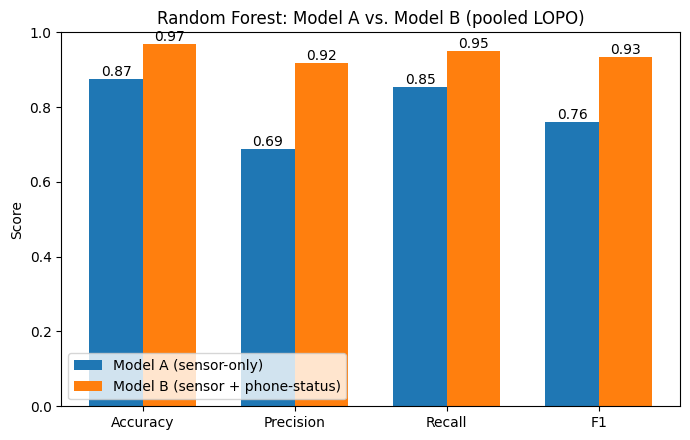

In [112]:
labels = ['accuracy', 'precision', 'recall', 'f1']
a_vals = [pooled_A['Random Forest'][m] for m in labels]
b_vals = [pooled_B['Random Forest'][m] for m in labels]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(x - width/2, a_vals, width, label='Model A (sensor-only)')
ax.bar(x + width/2, b_vals, width, label='Model B (sensor + phone-status)')
ax.set_ylabel('Score')
ax.set_title('Random Forest: Model A vs. Model B (pooled LOPO)')
ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in labels])
ax.set_ylim(0, 1)
ax.legend()
ax.bar_label(ax.containers[0], fmt='%.2f')
ax.bar_label(ax.containers[1], fmt='%.2f')
plt.tight_layout()
plt.show()
